['20260909210739', '20260909210822', '20260909210905', '20260909210949', '20260909211031', '20260909211115']


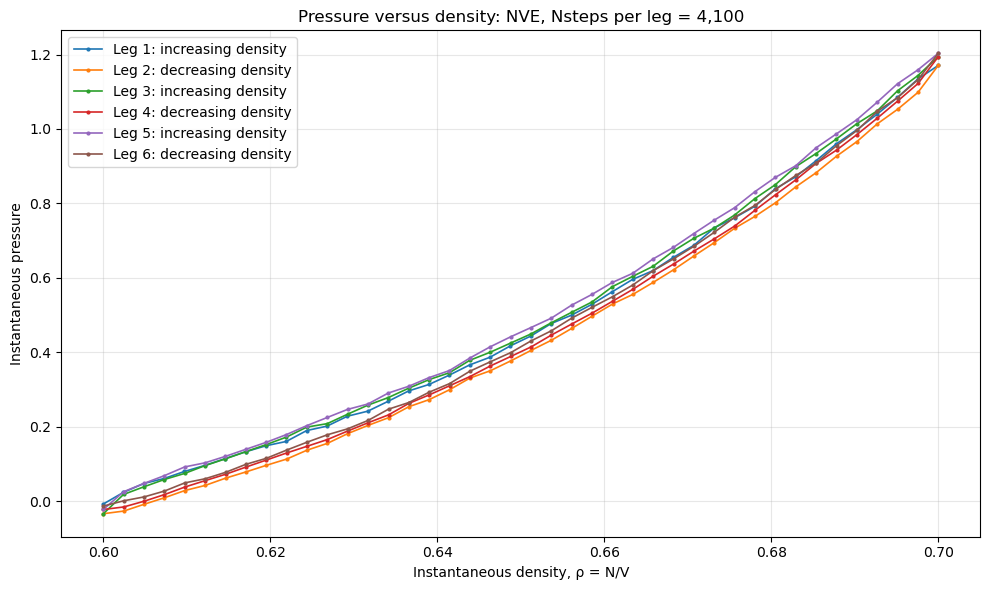

['20260909202024', '20260909202117', '20260909210024', '20260909210117', '20260909210237', '20260909210328']


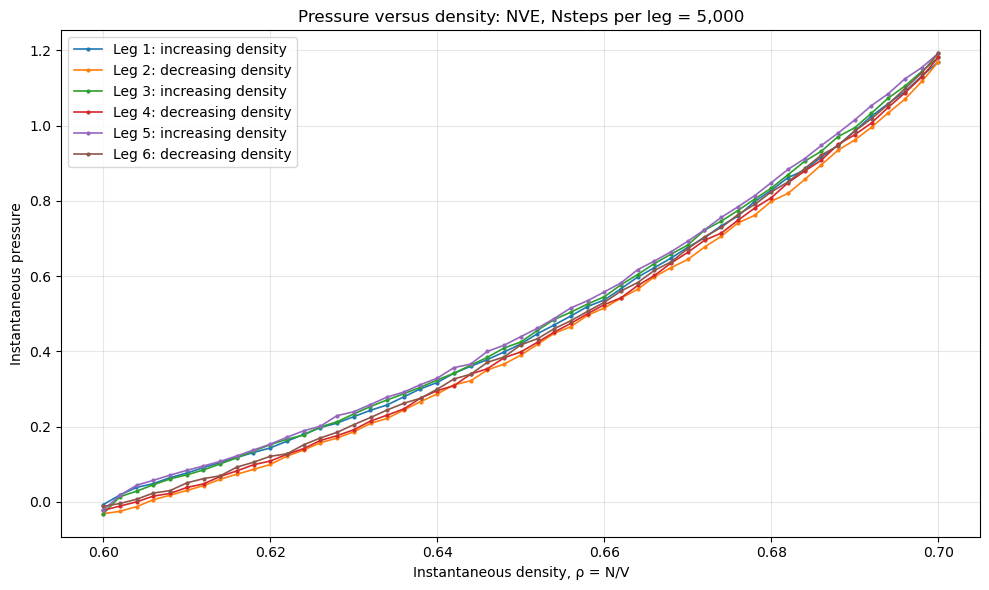

['20260909211159', '20260909211334', '20260909211509', '20260909211645', '20260909211822', '20260909211957']


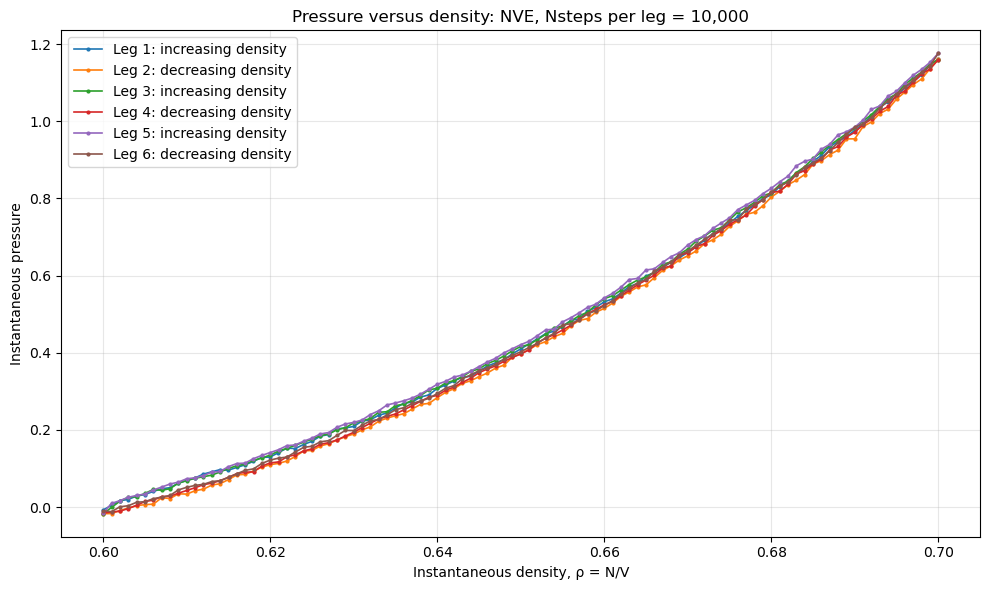

['20260909200906', '20260909201254', '20260909212134', '20260909212511', '20260909212850', '20260909213227']


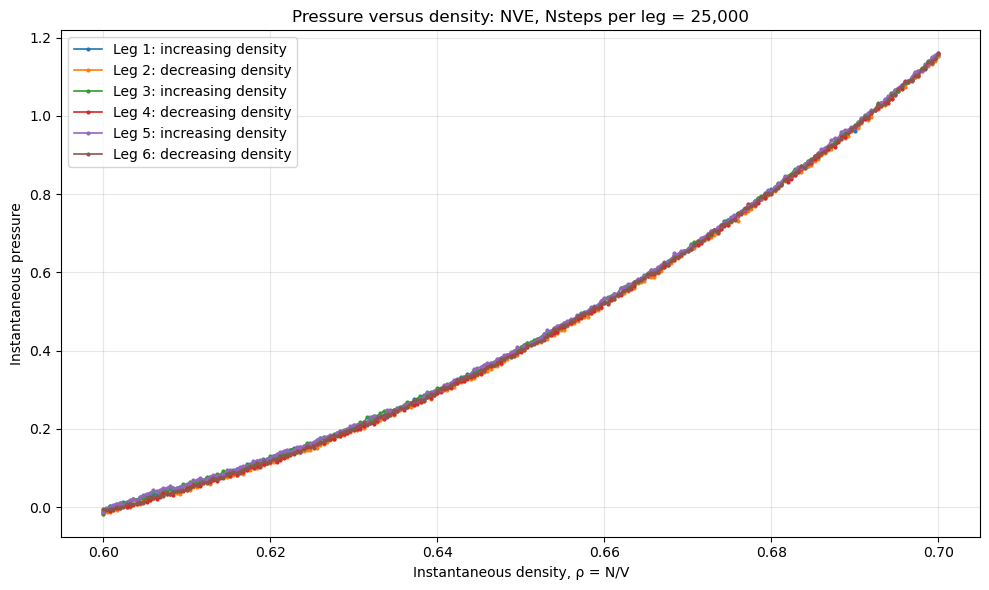

In [15]:
# Triangle rescaling
from md_Helpers import (
    ProjectPaths,
    SQLiteRunDatabase,
    open_run,
    run_clone_rescale_ensemble,
)

import matplotlib.pyplot as plt

database = SQLiteRunDatabase(ProjectPaths().database)

original_run = "20260909195450"
NStepTri = [4_100,5_000,10_000,25_000]
number_of_legs = 6  # Two complete up-and-down cycles

records = database.query_thermalizations(Run_ID=original_run)

if not records:
    raise ValueError(f"Run {original_run} was not found")

rho_og = float(records[0]["Density_End"])

# Start by increasing density, then return to the original density.
densities = [0.7, rho_og]

for nstepTri in NStepTri:
    Tri_Run_ID = []
    source_run_id = original_run
    
    for i in range(number_of_legs):
        target_density = densities[i % 2]
    
        direction = (
            "increasing density"
            if target_density > rho_og
            else "decreasing density"
        )
    
        nve_result = run_clone_rescale_ensemble(
            source_run_id=source_run_id,
            final_density=target_density,
            nsteps=nstepTri,
            ensemble="NVE",
            notes=f"Triangle NVE, leg {i + 1}: {direction}",
        )
    
        source_run_id = nve_result["run_id"]
        Tri_Run_ID.append(source_run_id)
    
    print(Tri_Run_ID)
    
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for leg, run_id in enumerate(Tri_Run_ID, start=1):
        logs = open_run(run_id).logs_dataframe()
    
        density = logs["num_particles"] / logs["volume"]
        pressure = logs["pressure"]
    
        direction = (
            "increasing density"
            if density.iloc[-1] > density.iloc[0]
            else "decreasing density"
        )
    
        ax.plot(
            density,
            pressure,
            marker=".",
            markersize=4,
            linewidth=1.2,
            label=f"Leg {leg}: {direction}",
        )
    
    ax.set_xlabel("Instantaneous density, ρ = N/V")
    ax.set_ylabel("Instantaneous pressure")
    ax.set_title(f"Pressure versus density: NVE, Nsteps per leg = {nstepTri:,}")
    ax.grid(alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()


Running triangle with 2,500 steps per leg
  Leg 1: increasing, Run_ID=20260910175541
  Leg 2: decreasing, Run_ID=20260910175615
  Leg 3: increasing, Run_ID=20260910175648
  Leg 4: decreasing, Run_ID=20260910175721
  Leg 5: increasing, Run_ID=20260910175753
  Leg 6: decreasing, Run_ID=20260910175827

Running triangle with 5,000 steps per leg
  Leg 1: increasing, Run_ID=20260910175900
  Leg 2: decreasing, Run_ID=20260910180001
  Leg 3: increasing, Run_ID=20260910180100
  Leg 4: decreasing, Run_ID=20260910180201
  Leg 5: increasing, Run_ID=20260910180259
  Leg 6: decreasing, Run_ID=20260910180359

Running triangle with 10,000 steps per leg
  Leg 1: increasing, Run_ID=20260910180500
  Leg 2: decreasing, Run_ID=20260910180653
  Leg 3: increasing, Run_ID=20260910180844
  Leg 4: decreasing, Run_ID=20260910181036
  Leg 5: increasing, Run_ID=20260910181228
  Leg 6: decreasing, Run_ID=20260910181423

Running triangle with 25,000 steps per leg
  Leg 1: increasing, Run_ID=20260910181616
  Leg 2: 

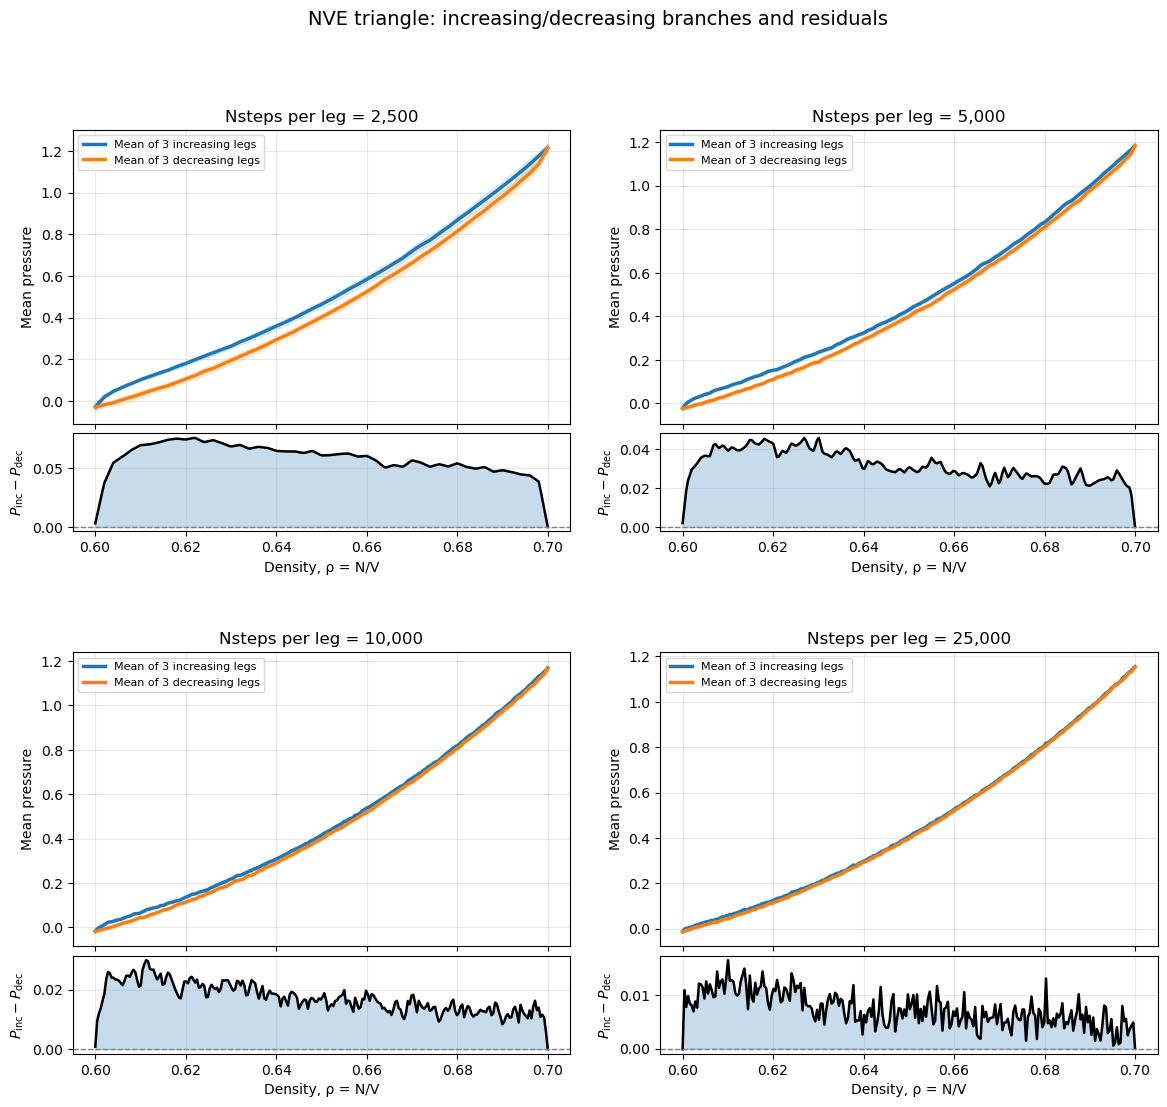

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from md_Helpers import (
    ProjectPaths,
    SQLiteRunDatabase,
    open_run,
    run_clone_rescale_ensemble,
)

# --------------------------------------------------
# Configuration
# --------------------------------------------------

database = SQLiteRunDatabase(ProjectPaths().database)

original_run = "20260910171124"

NStepTri = [
    2_500,
    5_000,
    10_000,
    25_000,
]

number_of_cycles = 3
number_of_legs = 2 * number_of_cycles

rho_high = 0.7
density_grid_points = 250
smoothing_window = 1

# --------------------------------------------------
# Read the original state
# --------------------------------------------------

records = database.query_thermalizations(
    Run_ID=original_run
)

if not records:
    raise ValueError(
        f"Run {original_run} was not found"
    )

# Cloning starts from the original run's final state.
rho_original = float(records[0]["Density_End"])

# First compress, then expand back.
target_densities = [
    rho_high,
    rho_original,
]

# Stores all generated run IDs by Nsteps.
triangle_runs = {}

# Stores averaged curves for plotting.
averaged_curves = {}

# --------------------------------------------------
# Run every triangle
# --------------------------------------------------

for nstepTri in NStepTri:
    print(f"\nRunning triangle with {nstepTri:,} steps per leg")

    source_run_id = original_run
    run_ids = []

    for leg_index in range(number_of_legs):
        target_density = target_densities[
            leg_index % 2
        ]

        direction = (
            "increasing"
            if target_density > rho_original
            else "decreasing"
        )

        result = run_clone_rescale_ensemble(
            source_run_id=source_run_id,
            final_density=target_density,
            nsteps=nstepTri,
            ensemble="NVE",
            notes=(
                f"Triangle NVE; "
                f"Nsteps={nstepTri}; "
                f"cycle={leg_index // 2 + 1}; "
                f"direction={direction}"
            ),
        )

        source_run_id = result["run_id"]
        run_ids.append(source_run_id)

        print(
            f"  Leg {leg_index + 1}: "
            f"{direction}, Run_ID={source_run_id}"
        )

    triangle_runs[nstepTri] = run_ids

    # --------------------------------------------------
    # Separate the runs by direction
    # --------------------------------------------------

    branches = {
        "increasing": [],
        "decreasing": [],
    }

    for run_id in run_ids:
        logs = open_run(run_id).logs_dataframe()

        density = logs["density"].to_numpy()
        pressure = logs["pressure"].to_numpy()

        direction = (
            "increasing"
            if density[-1] > density[0]
            else "decreasing"
        )

        branches[direction].append(
            (density, pressure)
        )

    averaged_curves[nstepTri] = {}

    # --------------------------------------------------
    # Average and smooth each direction
    # --------------------------------------------------

    for direction in [
        "increasing",
        "decreasing",
    ]:
        direction_runs = branches[direction]

        if len(direction_runs) != number_of_cycles:
            raise RuntimeError(
                f"Expected {number_of_cycles} "
                f"{direction} legs for "
                f"Nsteps={nstepTri}, but found "
                f"{len(direction_runs)}"
            )

        # Use only the density range shared by all runs.
        shared_rho_min = max(
            density.min()
            for density, _ in direction_runs
        )

        shared_rho_max = min(
            density.max()
            for density, _ in direction_runs
        )

        density_grid = np.linspace(
            shared_rho_min,
            shared_rho_max,
            density_grid_points,
        )

        interpolated_pressures = []

        for density, pressure in direction_runs:
            order = np.argsort(density)

            pressure_on_grid = np.interp(
                density_grid,
                density[order],
                pressure[order],
            )

            interpolated_pressures.append(
                pressure_on_grid
            )

        interpolated_pressures = np.asarray(
            interpolated_pressures
        )

        # Average all three complete legs.
        mean_pressure = (
            interpolated_pressures.mean(axis=0)
        )

        # Cycle-to-cycle standard deviation.
        pressure_std = (
            interpolated_pressures.std(
                axis=0,
                ddof=1,
            )
        )

        # Smooth only after averaging the three legs.
        smoothed_mean = (
            pd.Series(mean_pressure)
            .rolling(
                window=smoothing_window,
                center=True,
                min_periods=1,
            )
            .mean()
            .to_numpy()
        )

        averaged_curves[nstepTri][direction] = {
            "density": density_grid,
            "mean_pressure": mean_pressure,
            "smoothed_pressure": smoothed_mean,
            "pressure_std": pressure_std,
        }

# --------------------------------------------------
# Plot each ramp rate with its residual underneath
# --------------------------------------------------

fig = plt.figure(figsize=(14, 12))

outer_grid = fig.add_gridspec(
    2,
    2,
    hspace=0.30,
    wspace=0.18,
)

direction_styles = {
    "increasing": {
        "color": "tab:blue",
        "label": "Mean of 3 increasing legs",
    },
    "decreasing": {
        "color": "tab:orange",
        "label": "Mean of 3 decreasing legs",
    },
}

main_axes = []
residual_axes = []

for panel_index, nstepTri in enumerate(NStepTri):
    row, column = divmod(panel_index, 2)

    # Two vertically stacked axes inside each panel.
    inner_grid = outer_grid[row, column].subgridspec(
        2,
        1,
        height_ratios=[3, 1],
        hspace=0.05,
    )

    ax = fig.add_subplot(inner_grid[0])
    ax_residual = fig.add_subplot(
        inner_grid[1],
        sharex=ax,
    )

    main_axes.append(ax)
    residual_axes.append(ax_residual)

    # --------------------------------------------------
    # Main increasing/decreasing curves
    # --------------------------------------------------

    for direction in ["increasing", "decreasing"]:
        curve = averaged_curves[nstepTri][direction]
        style = direction_styles[direction]

        density = curve["density"]
        smoothed = curve["smoothed_pressure"]
        std = curve["pressure_std"]

        ax.plot(
            density,
            smoothed,
            color=style["color"],
            linewidth=2.5,
            label=style["label"],
        )

        ax.fill_between(
            density,
            smoothed - std,
            smoothed + std,
            color=style["color"],
            alpha=0.12,
        )

    # --------------------------------------------------
    # Increasing-minus-decreasing residual
    # --------------------------------------------------

    increasing = averaged_curves[nstepTri]["increasing"]
    decreasing = averaged_curves[nstepTri]["decreasing"]

    # Restrict comparison to the density range shared
    # by both averaged branches.
    residual_rho_min = max(
        increasing["density"].min(),
        decreasing["density"].min(),
    )

    residual_rho_max = min(
        increasing["density"].max(),
        decreasing["density"].max(),
    )

    residual_density = np.linspace(
        residual_rho_min,
        residual_rho_max,
        density_grid_points,
    )

    increasing_pressure = np.interp(
        residual_density,
        increasing["density"],
        increasing["smoothed_pressure"],
    )

    decreasing_pressure = np.interp(
        residual_density,
        decreasing["density"],
        decreasing["smoothed_pressure"],
    )

    residual = (
        increasing_pressure
        - decreasing_pressure
    )

    ax_residual.plot(
        residual_density,
        residual,
        color="black",
        linewidth=1.8,
    )

    ax_residual.fill_between(
        residual_density,
        0,
        residual,
        where=residual >= 0,
        color="tab:blue",
        alpha=0.25,
        interpolate=True,
        label="Increasing > decreasing",
    )

    ax_residual.fill_between(
        residual_density,
        0,
        residual,
        where=residual < 0,
        color="tab:orange",
        alpha=0.25,
        interpolate=True,
        label="Increasing < decreasing",
    )

    ax_residual.axhline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1,
    )

    # --------------------------------------------------
    # Labels and formatting
    # --------------------------------------------------

    ax.set_title(
        f"Nsteps per leg = {nstepTri:,}"
    )
    ax.set_ylabel("Mean pressure")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    # Hide the main panel's x-axis labels because the
    # residual panel supplies them.
    ax.tick_params(
        axis="x",
        labelbottom=False,
    )

    ax_residual.set_xlabel("Density, ρ = N/V")
    ax_residual.set_ylabel(
        r"$P_{\mathrm{inc}}-P_{\mathrm{dec}}$"
    )
    ax_residual.grid(alpha=0.3)

fig.suptitle(
    "NVE triangle: increasing/decreasing branches and residuals",
    fontsize=14,
)

plt.show()


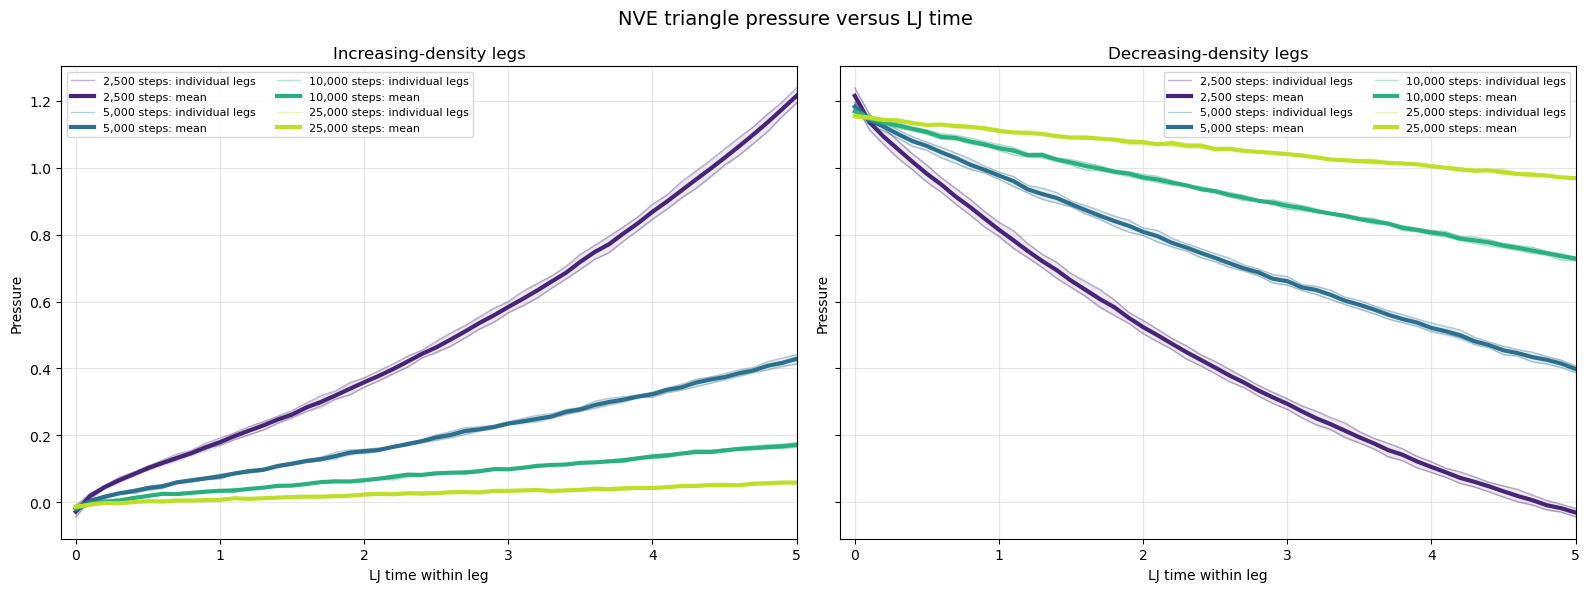

In [14]:
# --------------------------------------------------
# Pressure versus LJ time for every individual leg
# and the average at each Nsteps
# --------------------------------------------------

fig, (ax_inc, ax_dec) = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    sharey=True,
)

direction_axes = {
    "increasing": ax_inc,
    "decreasing": ax_dec,
}

# One color for each Nsteps value.
colors = plt.cm.viridis(
    np.linspace(0.1, 0.9, len(NStepTri))
)

# Store the time-domain averages if they are needed later.
time_averaged_curves = {}

for color, nstepTri in zip(colors, NStepTri):
    time_averaged_curves[nstepTri] = {}

    # Collect individual legs by direction.
    time_branches = {
        "increasing": [],
        "decreasing": [],
    }

    for run_id in triangle_runs[nstepTri]:
        logs = open_run(run_id).logs_dataframe()

        lj_time = logs["this_lj_time"].to_numpy(
            dtype=float
        )
        density = logs["density"].to_numpy(
            dtype=float
        )
        pressure = logs["pressure"].to_numpy(
            dtype=float
        )

        direction = (
            "increasing"
            if density[-1] > density[0]
            else "decreasing"
        )

        # Sort by LJ time before interpolating.
        order = np.argsort(lj_time)
        lj_time = lj_time[order]
        pressure = pressure[order]

        # Remove duplicate time points, if any.
        lj_time, unique_indices = np.unique(
            lj_time,
            return_index=True,
        )
        pressure = pressure[unique_indices]

        time_branches[direction].append(
            {
                "run_id": run_id,
                "time": lj_time,
                "pressure": pressure,
            }
        )

    # --------------------------------------------------
    # Plot each direction
    # --------------------------------------------------

    for direction in ["increasing", "decreasing"]:
        ax = direction_axes[direction]
        runs = time_branches[direction]

        if len(runs) != number_of_cycles:
            raise RuntimeError(
                f"Expected {number_of_cycles} {direction} "
                f"legs for Nsteps={nstepTri:,}, "
                f"but found {len(runs)}"
            )

        # Plot every individual cycle.
        for cycle_index, run_data in enumerate(runs):
            ax.plot(
                run_data["time"],
                run_data["pressure"],
                color=color,
                linewidth=1,
                alpha=0.35,
                label=(
                    f"{nstepTri:,} steps: individual legs"
                    if cycle_index == 0
                    else None
                ),
            )

        # Use the LJ-time interval shared by all three legs.
        shared_time_min = max(
            run_data["time"].min()
            for run_data in runs
        )
        shared_time_max = min(
            run_data["time"].max()
            for run_data in runs
        )

        # Use enough points to retain the resolution of
        # the most densely logged run.
        time_grid_points = max(
            len(run_data["time"])
            for run_data in runs
        )

        time_grid = np.linspace(
            shared_time_min,
            shared_time_max,
            time_grid_points,
        )

        pressure_on_grid = np.asarray([
            np.interp(
                time_grid,
                run_data["time"],
                run_data["pressure"],
            )
            for run_data in runs
        ])

        mean_pressure = pressure_on_grid.mean(axis=0)
        pressure_std = pressure_on_grid.std(
            axis=0,
            ddof=1,
        )

        # Uses the smoothing_window defined in the
        # preceding cell. With smoothing_window=1,
        # no smoothing is applied.
        smoothed_mean = (
            pd.Series(mean_pressure)
            .rolling(
                window=smoothing_window,
                center=True,
                min_periods=1,
            )
            .mean()
            .to_numpy()
        )

        time_averaged_curves[nstepTri][direction] = {
            "lj_time": time_grid,
            "mean_pressure": mean_pressure,
            "smoothed_pressure": smoothed_mean,
            "pressure_std": pressure_std,
        }

        # Plot the average prominently.
        ax.plot(
            time_grid,
            smoothed_mean,
            color=color,
            linewidth=3,
            label=f"{nstepTri:,} steps: mean",
        )

        # Optional cycle-to-cycle standard-deviation band.
        ax.fill_between(
            time_grid,
            smoothed_mean - pressure_std,
            smoothed_mean + pressure_std,
            color=color,
            alpha=0.10,
        )

# --------------------------------------------------
# Formatting
# --------------------------------------------------

ax_inc.set_xlim(-.1, 5)
ax_dec.set_xlim(-.1, 5)



ax_inc.set_title("Increasing-density legs")
ax_dec.set_title("Decreasing-density legs")

for ax in (ax_inc, ax_dec):
    ax.set_xlabel("LJ time within leg")
    ax.set_ylabel("Pressure")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

fig.suptitle(
    "NVE triangle pressure versus LJ time",
    fontsize=14,
)

plt.tight_layout()
plt.show()